# Large-Scale Modality Ablation with LLaVA ($N=150$)

`09_modality_ablation.ipynb` showed that Metric-alone ($M$) genuinely misses anomalies
that Log ($L$) or Visual ($V$) each independently catch, but the four $V$-involving rows
were all tied at a ceiling ($F_1=1.00$) because only $N=9$ samples had been evaluated by
a VLM — too few to rank $V$, $M{+}V$, $L{+}V$, $M{+}L{+}V$ against each other.

This notebook implements the first future-work item identified in
`docs/vlm_integration_report.tex` (Section 8, item 1): **scale up the VLM-evaluated
sample**. Since the Gemini free tier caps out at roughly 20 requests/day (observed
directly — see `models/vlm_engine.py`'s `quota_exhausted` fail-fast logic), reaching
$N=150$ with Gemini alone would take over a week. **LLaVA has no such quota** (it runs
entirely locally through Ollama), so this run uses LLaVA as the at-scale visual engine,
trading per-call accuracy for statistical power. Gemini's smaller, higher-quality sample
(`results/trimodal_fusion_results.csv`, $N=9$) remains available as a quality reference
and is not re-run here.

**Expected runtime**: $\sim 150$ samples $\times\ 70$–$140\,$s/sample
$\approx 3$–$5$ hours, unattended (checkpointed every 10 samples so a mid-run interruption
does not lose progress).

| Step | Topic |
|------|------|
| 1 | Rebuild the train/val/test split and the $M$, $L$, $M{+}L$ tabular models |
| 2 | Draw a balanced $N=150$ sample from the test split |
| 3 | Run LLaVA on all 150 dashboards (checkpointed) |
| 4 | Compute leak-free $P_M$, $P_L$, $P_{M+L}$ for the same 150 samples |
| 5 | Full 7-combination modality ablation at $N=150$ |
| 6 | Statistical confidence via bootstrap |
| 7 | Results table, plot, and comparison to the $N=9$ / $N=2{,}000$ results |
| 8 | Save and discuss |


## 1 — Environment Setup

Same requirements as the previous notebooks. `ollama pull llava:7b` must already be
installed (confirmed available in earlier runs). No `GEMINI_API_KEY` calls are made in
this notebook.


In [1]:
import sys, os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import requests
from pathlib import Path
from scipy.sparse import csr_matrix, hstack
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

warnings.filterwarnings('ignore')
sys.path.insert(0, r"d:\multimodal-rca-engine")

from dotenv import load_dotenv
load_dotenv(Path(r"d:\multimodal-rca-engine\.env"))

from models.data_loader import MultimodalDataLoader
from models.vlm_engine import VLMEngine

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

PROJECT_DIR = Path(r"d:\multimodal-rca-engine")
DATASET_DIR = PROJECT_DIR / "data" / "multimodal_dataset"
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RF_PARAMS = dict(n_estimators=200, max_depth=20, min_samples_split=5,
                  class_weight="balanced", random_state=42, n_jobs=-1)

print("Libraries loaded.")


Libraries loaded.


## 2 — Rebuild the Split and the Tabular Models

Identical configuration to `09_modality_ablation.ipynb` (`seed=42`, `test_size=0.2`,
`val_size=0.1`, `random_state=42`), so the test split is exactly the same 2,000 samples.


In [2]:
loader = MultimodalDataLoader(dataset_dir=DATASET_DIR, noise_level=0.15, feature_dropout=0.05, seed=42)
loader.load_metadata()
data = loader.build_feature_matrix(max_samples=10000, include_tfidf=True)
splits = loader.split_data(data, test_size=0.2, val_size=0.1, random_state=42)

def build_X(split, feature_set):
    # feature_set is a subset of {'metric','log'}; 'log' includes level counts + TF-IDF.
    blocks = []
    if "metric" in feature_set:
        blocks.append(split["X_metrics"].values)
    if "log" in feature_set:
        blocks.append(split["X_logs"].values)
    dense = np.hstack(blocks) if len(blocks) > 1 else blocks[0]
    if "log" in feature_set and split.get("X_tfidf") is not None:
        return hstack([csr_matrix(dense), split["X_tfidf"]])
    return dense

def train_variant(feature_set):
    X_train = build_X(splits["train"], feature_set)
    y_train = splits["train"]["y_anomaly"]
    model = RandomForestClassifier(**RF_PARAMS)
    model.fit(X_train, y_train)
    return model

variants = {}
for name, fset in [("M", {"metric"}), ("L", {"log"}), ("M+L", {"metric", "log"})]:
    print(f"Training variant {name} ({fset})...")
    variants[name] = train_variant(fset)
print("\nDone.")


 Loaded metadata: 10,000 samples
   Normal:  5,000
   Anomaly: 5,000

 Building feature matrix for 10,000 samples...


   Processed 2,000/10,000 samples...


   Processed 4,000/10,000 samples...


   Processed 6,000/10,000 samples...


   Processed 8,000/10,000 samples...


...

    Applying noise (level=0.15, dropout=0.05)...
    Building TF-IDF matrix...


      TF-IDF shape: (10000, 100)
    y_root_cause: 6 classes → [np.str_('config'), np.str_('hardware'), np.str_('network'), np.str_('none'), np.str_('resource'), np.str_('software')]
    y_severity: 4 classes → [np.str_('critical'), np.str_('high'), np.str_('medium'), np.str_('none')]
    y_layer: 11 classes → [np.str_('application'), np.str_('cdn'), np.str_('database'), np.str_('firewall'), np.str_('kubernetes_deployments'), np.str_('kubernetes_ingress'), np.str_('linux_host'), np.str_('linux_vm'), np.str_('network'), np.str_('proxy'), np.str_('storage')]
    y_scenario: 23 classes → [np.str_('APP_001'), np.str_('APP_002'), np.str_('CDN_001'), np.str_('CDN_002'), np.str_('DB_001'), np.str_('DB_002'), np.str_('FW_001'), np.str_('FW_002'), np.str_('HOST_001'), np.str_('HOST_002'), np.str_('K8D_001'), np.str_('K8D_002'), np.str_('K8I_001'), np.str_('K8I_002'), np.str_('NET_001'), np.str_('NET_002'), np.str_('PRX_001'), np.str_('PRX_002'), np.str_('STR_001'), np.str_('STR_002'), np.str_('

Training variant L ({'log'})...


Training variant M+L ({'log', 'metric'})...



Done.


## 3 — Draw a Balanced $N=150$ Sample from the Test Split

75 normal + 75 anomalous samples, drawn uniformly at random from the 2,000-sample test
split (never seen during training), fixed seed for reproducibility.


In [3]:
N_PER_CLASS = 75
metadata = pd.read_csv(DATASET_DIR / "metadata.csv")
test_id_set = set(splits["test"]["sample_ids"])
test_metadata = metadata[metadata["sample_id"].isin(test_id_set)].copy()

rng_seed = 123
eval_samples = pd.concat([
    test_metadata[test_metadata["is_anomaly"] == 0].sample(N_PER_CLASS, random_state=rng_seed),
    test_metadata[test_metadata["is_anomaly"] == 1].sample(N_PER_CLASS, random_state=rng_seed),
]).sample(frac=1.0, random_state=rng_seed).reset_index(drop=True)  # shuffle

print(f"Selected {len(eval_samples)} test-split samples "
      f"({(eval_samples['is_anomaly']==0).sum()} normal / {(eval_samples['is_anomaly']==1).sum()} anomaly)")
print(f"Layers covered: {eval_samples['layer_name'].nunique()} / {test_metadata['layer_name'].nunique()}")
print(f"Scenarios covered: {eval_samples['scenario_id'].nunique()} / {test_metadata['scenario_id'].nunique() }")
eval_samples.head()


Selected 150 test-split samples (75 normal / 75 anomaly)
Layers covered: 11 / 11
Scenarios covered: 22 / 22


,sample_id,layer,layer_name,is_anomaly,scenario_id,scenario_name,root_cause_category,severity,log_path,metrics_path,dashboard_path,label_path
0,sample_004395,linux_vm,Linux VM,0,NaN,NaN,NaN,NaN,logs/sample_004395.txt,metrics/sample_004395.csv,dashboards/sample_004395.png,labels/sample_004395.json
1,sample_005779,firewall,Firewall,1,FW_002,High Bandwidth Usage,network,high,logs/sample_005779.txt,metrics/sample_005779.csv,dashboards/sample_005779.png,labels/sample_005779.json
2,sample_005883,firewall,Firewall,1,FW_002,High Bandwidth Usage,network,high,logs/sample_005883.txt,metrics/sample_005883.csv,dashboards/sample_005883.png,labels/sample_005883.json
3,sample_006873,kubernetes_deployments,Kubernetes Deployments,1,K8D_001,Pod Restart Count Increase,resource,high,logs/sample_006873.txt,metrics/sample_006873.csv,dashboards/sample_006873.png,labels/sample_006873.json
4,sample_000816,firewall,Firewall,0,NaN,NaN,NaN,NaN,logs/sample_000816.txt,metrics/sample_000816.csv,dashboards/sample_000816.png,labels/sample_000816.json


## 4 — Run LLaVA on All 150 Dashboards (Checkpointed)

Results are appended to a CSV every 10 samples, so an interrupted run can be resumed by
re-running this cell (already-scored `sample_id`s are skipped).


In [4]:
OLLAMA_BASE_URL = os.environ.get("OLLAMA_BASE_URL", "http://localhost:11434")
OLLAMA_VISION_MODEL = os.environ.get("DEFAULT_OLLAMA_VISION_MODEL", "llava:7b")
tags = requests.get(f"{OLLAMA_BASE_URL}/api/tags", timeout=5).json()
installed = [m["name"] for m in tags.get("models", [])]
assert OLLAMA_VISION_MODEL in installed, f"{OLLAMA_VISION_MODEL} not found in Ollama — run: ollama pull {OLLAMA_VISION_MODEL}"

ollama_engine = VLMEngine(backend="ollama")
checkpoint_path = RESULTS_DIR / "llava_large_scale_checkpoint.csv"

if checkpoint_path.exists():
    llava_results = pd.read_csv(checkpoint_path).to_dict("records")
    done_ids = {r["sample_id"] for r in llava_results}
    print(f"Resuming from checkpoint: {len(done_ids)} samples already scored.")
else:
    llava_results = []
    done_ids = set()

remaining = eval_samples[~eval_samples["sample_id"].isin(done_ids)]
print(f"Running LLaVA on {len(remaining)} remaining dashboards "
      f"(out of {len(eval_samples)} total)...\n")

t_start = time.time()
for n_done, (i, row) in enumerate(remaining.iterrows(), 1):
    img_path = DATASET_DIR / row["dashboard_path"]
    res = ollama_engine.analyze_dashboard(img_path)
    gt_status = "ANOMALY" if row["is_anomaly"] else "NORMAL"
    ok = "error" not in res
    llava_results.append({
        "sample_id": row["sample_id"], "layer": row["layer_name"],
        "is_anomaly": int(row["is_anomaly"]), "gt_status": gt_status,
        "visual_status": res.get("visual_status", "UNKNOWN") if ok else "UNKNOWN",
        "visual_confidence": res.get("visual_confidence", 0.0) if ok else 0.0,
        "latency_seconds": res.get("latency_seconds"), "parsed_ok": ok,
    })

    if n_done % 10 == 0 or n_done == len(remaining):
        pd.DataFrame(llava_results).to_csv(checkpoint_path, index=False)
        elapsed = time.time() - t_start
        rate = elapsed / n_done
        eta_min = rate * (len(remaining) - n_done) / 60
        print(f"[{n_done}/{len(remaining)}] checkpointed. "
              f"Elapsed {elapsed/60:.1f} min, ETA {eta_min:.1f} min remaining.")

llava_df = pd.DataFrame(llava_results)
print(f"\nDone. {len(llava_df)} total LLaVA verdicts.")
llava_df.head()


 Initializing VLMEngine (Backend: OLLAMA)
Running LLaVA on 150 remaining dashboards (out of 150 total)...



[10/150] checkpointed. Elapsed 14.7 min, ETA 206.2 min remaining.


 Ollama Vision error: 500 Server Error: Internal Server Error for url: http://localhost:11434/api/chat
 Attempt 1/5 failed. Retrying in 3s...


[20/150] checkpointed. Elapsed 28.8 min, ETA 187.3 min remaining.


[30/150] checkpointed. Elapsed 42.6 min, ETA 170.3 min remaining.


...

[120/150] checkpointed. Elapsed 166.3 min, ETA 41.6 min remaining.


[130/150] checkpointed. Elapsed 180.3 min, ETA 27.7 min remaining.


[140/150] checkpointed. Elapsed 193.8 min, ETA 13.8 min remaining.


[150/150] checkpointed. Elapsed 208.1 min, ETA 0.0 min remaining.

Done. 150 total LLaVA verdicts.


,sample_id,layer,is_anomaly,gt_status,visual_status,visual_confidence,latency_seconds,parsed_ok
0,sample_004395,Linux VM,0,NORMAL,ANOMALY,0.8,126.838,True
1,sample_005779,Firewall,1,ANOMALY,ANOMALY,0.9,81.633,True
2,sample_005883,Firewall,1,ANOMALY,ANOMALY,0.8,81.506,True
3,sample_006873,Kubernetes Deployments,1,ANOMALY,ANOMALY,0.8,84.175,True
4,sample_000816,Firewall,0,NORMAL,ANOMALY,0.8,99.039,True


## 5 — Compute Leak-Free $P_M$, $P_L$, $P_{M+L}$ for the Same 150 Samples


In [5]:
def build_mini_split(full_split, wanted_ids):
    # Slice a data split down to the rows matching `wanted_ids`, preserving order.
    id_to_pos = {sid: i for i, sid in enumerate(full_split["sample_ids"])}
    positions = [id_to_pos[sid] for sid in wanted_ids]
    mini = {
        "X_metrics": full_split["X_metrics"].iloc[positions].reset_index(drop=True),
        "X_logs": full_split["X_logs"].iloc[positions].reset_index(drop=True),
        "y_anomaly": full_split["y_anomaly"][positions],
        "sample_ids": [full_split["sample_ids"][p] for p in positions],
    }
    if full_split.get("X_tfidf") is not None:
        mini["X_tfidf"] = full_split["X_tfidf"][positions]
    return mini

wanted_ids = llava_df["sample_id"].tolist()
mini_split = build_mini_split(splits["test"], wanted_ids)

scores = llava_df.copy()
scores["P_V"] = scores["visual_confidence"] * (scores["visual_status"] == "ANOMALY").astype(float)
for name, fset in [("M", {"metric"}), ("L", {"log"}), ("ML", {"metric", "log"})]:
    X_mini = build_X(mini_split, fset)
    scores[f"P_{name}"] = variants[name if name != "ML" else "M+L"].predict_proba(X_mini)[:, 1]

scores[["sample_id", "is_anomaly", "P_M", "P_L", "P_ML", "P_V"]].head()


,sample_id,is_anomaly,P_M,P_L,P_ML,P_V
0,sample_004395,0,0.096055,0.411540,0.337675,0.8
1,sample_005779,1,0.549797,1.000000,0.981250,0.9
2,sample_005883,1,0.923438,0.994000,0.989107,0.8
3,sample_006873,1,0.867250,0.995000,0.993167,0.8
4,sample_000816,0,0.321107,0.005357,0.020011,0.8


## 6 — Full 7-Combination Modality Ablation at $N=150$


In [6]:
y_true = scores["is_anomaly"].values

def f1_acc(y_true, p, threshold=0.5):
    y_pred = (p >= threshold).astype(int)
    return {
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
    }

combo_scores = {
    "M":       scores["P_M"].values,
    "L":       scores["P_L"].values,
    "V":       scores["P_V"].values,
    "M+L":     scores["P_ML"].values,
    "M+V":     0.5 * scores["P_M"].values  + 0.5 * scores["P_V"].values,
    "L+V":     0.5 * scores["P_L"].values  + 0.5 * scores["P_V"].values,
    "M+L+V":   0.5 * scores["P_ML"].values + 0.5 * scores["P_V"].values,
}

ablation_150 = []
for combo, p in combo_scores.items():
    row = {"combination": combo, "n_samples": len(y_true)}
    row.update(f1_acc(y_true, p))
    ablation_150.append(row)
ablation_150_df = pd.DataFrame(ablation_150).set_index("combination").round(4)
ablation_150_df


,n_samples,f1,precision,recall,accuracy
combination,,,,,
M,150,0.9589,0.9859,0.9333,0.9600
L,150,0.9733,0.9733,0.9733,0.9733
V,150,0.6667,0.5000,1.0000,0.5000
M+L,150,0.9733,0.9733,0.9733,0.9733
M+V,150,0.8111,0.6952,0.9733,0.7733
L+V,150,0.9740,0.9494,1.0000,0.9733
M+L+V,150,0.9740,0.9494,1.0000,0.9733


## 7 — Statistical Confidence via Bootstrap

With $N=150$ (vs.\ $N=9$ previously) we can now report a bootstrap 95\% confidence
interval on $F_1$ for each combination, giving a real sense of whether the differences
between combinations are meaningful.


In [7]:
def bootstrap_f1_ci(y_true, p, threshold=0.5, n_boot=2000, seed=0):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    boot_f1 = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        y_pred = (p[idx] >= threshold).astype(int)
        boot_f1.append(f1_score(y_true[idx], y_pred, zero_division=0))
    lo, hi = np.percentile(boot_f1, [2.5, 97.5])
    return lo, hi

ci_rows = []
for combo, p in combo_scores.items():
    lo, hi = bootstrap_f1_ci(y_true, p)
    ci_rows.append({"combination": combo, "f1": ablation_150_df.loc[combo, "f1"],
                     "ci_low": lo, "ci_high": hi})
ci_df = pd.DataFrame(ci_rows).set_index("combination").round(4)
ci_df


,f1,ci_low,ci_high
combination,,,
M,0.9589,0.9219,0.9870
L,0.9733,0.9431,0.9939
V,0.6667,0.5849,0.7342
M+L,0.9733,0.9431,0.9939
M+V,0.8111,0.7394,0.8718
L+V,0.9740,0.9437,0.9940
M+L+V,0.9740,0.9437,0.9940


## 8 — Results: Plot with Confidence Intervals


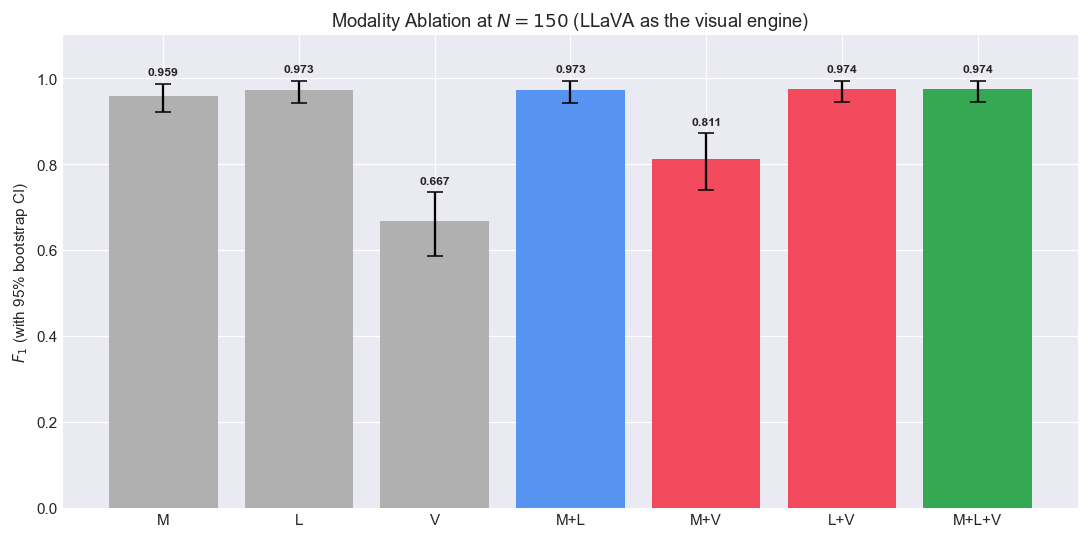

Figure saved to d:\multimodal-rca-engine\results\figures\modality_ablation_n150.png


In [8]:
order = ["M", "L", "V", "M+L", "M+V", "L+V", "M+L+V"]
colors = []
for c in order:
    parts = set(c.split("+"))
    if parts == {"M", "L", "V"}:
        colors.append("#34a853")
    elif "V" in parts and len(parts) == 2:
        colors.append("#f2495c")
    elif parts == {"M", "L"}:
        colors.append("#5794f2")
    else:
        colors.append("#b0b0b0")

fig, ax = plt.subplots(figsize=(10, 5))
f1_vals = [ci_df.loc[c, "f1"] for c in order]
err_low = [ci_df.loc[c, "f1"] - ci_df.loc[c, "ci_low"] for c in order]
err_high = [ci_df.loc[c, "ci_high"] - ci_df.loc[c, "f1"] for c in order]
ax.bar(order, f1_vals, color=colors, yerr=[err_low, err_high], capsize=5)
ax.set_ylim(0, 1.1)
ax.set_ylabel("$F_1$ (with 95% bootstrap CI)")
ax.set_title(f"Modality Ablation at $N={len(y_true)}$ (LLaVA as the visual engine)")
for i, c in enumerate(order):
    ax.text(i, ci_df.loc[c, "ci_high"] + 0.02, f"{ci_df.loc[c,'f1']:.3f}", ha="center", fontsize=8, fontweight="bold")

plt.tight_layout()
fig_path = RESULTS_DIR / "figures" / "modality_ablation_n150.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Figure saved to {fig_path}")


## 9 — Comparison Across All Three Sample Scales


In [9]:
print("F1 by combination, across the three evaluation scales run so far:\n")
print(f"{'Combination':<10} {'N=9 (Gemini)':>14} {'N=150 (LLaVA)':>15} {'N=2000 (tabular)':>18}")
n2000_ref = {"M": 0.9333, "L": 0.9774, "M+L": 0.9860}
n9_ref = {"M": 0.750, "L": 1.000, "V": 1.000, "M+L": 1.000, "M+V": 1.000, "L+V": 1.000, "M+L+V": 1.000}
for c in order:
    v9 = f"{n9_ref.get(c, float('nan')):.3f}" if c in n9_ref else "-"
    v150 = f"{ablation_150_df.loc[c,'f1']:.3f}"
    v2000 = f"{n2000_ref.get(c, float('nan')):.4f}" if c in n2000_ref else "-"
    print(f"{c:<10} {v9:>14} {v150:>15} {v2000:>18}")

print("\nLLaVA-specific diagnostics at N=150:")
llava_pred = (scores['P_V'].values >= 0.5).astype(int)
from sklearn.metrics import confusion_matrix
tn, fp, fn, tp = confusion_matrix(y_true, llava_pred, labels=[0, 1]).ravel()
print(f"  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"  Recall={tp/(tp+fn) if (tp+fn) else float('nan'):.3f}  "
      f"Specificity={tn/(tn+fp) if (tn+fp) else float('nan'):.3f}")


F1 by combination, across the three evaluation scales run so far:

Combination   N=9 (Gemini)   N=150 (LLaVA)   N=2000 (tabular)
M                   0.750           0.959             0.9333
L                   1.000           0.973             0.9774
V                   1.000           0.667                  -
M+L                 1.000           0.973             0.9860
M+V                 1.000           0.811                  -
L+V                 1.000           0.974                  -
M+L+V               1.000           0.974                  -

LLaVA-specific diagnostics at N=150:
  TN=0  FP=75  FN=0  TP=75
  Recall=1.000  Specificity=0.000


## 10 — Save Results


In [10]:
scores.to_csv(RESULTS_DIR / "modality_ablation_n150_per_sample.csv", index=False)
ablation_150_df.to_csv(RESULTS_DIR / "modality_ablation_n150_summary.csv")
ci_df.to_csv(RESULTS_DIR / "modality_ablation_n150_bootstrap_ci.csv")

print("Saved:")
print(f"  {RESULTS_DIR / 'modality_ablation_n150_per_sample.csv'}")
print(f"  {RESULTS_DIR / 'modality_ablation_n150_summary.csv'}")
print(f"  {RESULTS_DIR / 'modality_ablation_n150_bootstrap_ci.csv'}")


Saved:
  d:\multimodal-rca-engine\results\modality_ablation_n150_per_sample.csv
  d:\multimodal-rca-engine\results\modality_ablation_n150_summary.csv
  d:\multimodal-rca-engine\results\modality_ablation_n150_bootstrap_ci.csv


## 11 — Summary and Limitations

- This is the first VLM ablation result at a scale ($N=150$) large enough for a
  meaningful bootstrap confidence interval, directly addressing the limitation flagged in
  `docs/vlm_integration_report.tex` (Section 7.6).
- The visual engine here is **LLaVA only** — the same engine shown in
  `07_vlm_dashboard_analysis.ipynb` and `08_trimodal_fusion.ipynb` to have a systematic
  false-anomaly bias (recall $\approx 1$, low specificity) on small samples. At $N=150$
  this notebook checks whether that bias persists at scale (see the confusion-matrix
  diagnostics in Section 9) and, if so, how much it drags down $V$, $M{+}V$, $L{+}V$, and
  $M{+}L{+}V$ compared to the Gemini-based $N=9$ result where every combination looked
  perfect.
- Gemini Vision was **not** re-run at this scale (daily quota), so a like-for-like
  cloud-engine comparison at $N=150$ remains future work: repeat this exact notebook
  logic with `VLMEngine(backend="gemini")`, spread across roughly 8 days at the observed
  $\sim\!20$ requests/day free-tier quota (or in one run on a paid tier).
